Load & inspect Data Set

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
 
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
 
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
 


In [21]:
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)
 
# --- 4a. Shapes as a table ---
shape_table = pd.DataFrame(
    {"Rows": [train.shape[0], test.shape[0]],
     "Columns": [train.shape[1], test.shape[1]]},
    index=["train.csv", "test.csv"],
)

display(shape_table)

,Rows,Columns
train.csv,100000,28
test.csv,50000,27


In [22]:
print(train.head())

       ID Customer_ID     Month           Name   Age          SSN Occupation Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate Num_of_Loan  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist      19114.12                    NaN                  3                4              3           4   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist      19114.12                    NaN                  3                4              3           4   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist      19114.12                    NaN                  3                4              3           4   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist      19114.12          

In [23]:
print(test.head())

       ID Customer_ID      Month             Name  Age          SSN Occupation Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate Num_of_Loan  \
0  0x160a   CUS_0xd40  September    Aaron Maashoh   23  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4   
1  0x160b   CUS_0xd40    October    Aaron Maashoh   24  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4   
2  0x160c   CUS_0xd40   November    Aaron Maashoh   24  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4   
3  0x160d   CUS_0xd40   December    Aaron Maashoh  24_  821-00-0265  Scientist      19114.12                    NaN                  3                4              3           4   
4  0x1616  CUS_0x21b1  September  Rick Rothackerj   28  004-07-5839    _______      34847.

Cleaning & then showing train dataset on table


In [24]:
import pandas as pd
import numpy as np

# 1. Load your dataset
df = pd.read_csv('train.csv') 

# 2. Drop uninformative identifiers immediately
# Note: Retaining Customer_ID for grouping/imputation as requested
cols_to_drop = ['ID', 'Name', 'SSN']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3. Clean dirty text/special symbols from numeric columns and force numeric types
cols_to_clean = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.rstrip('_')
        df[col] = df[col].replace(r'^__.*__$', np.nan, regex=True)
        df[col] = df[col].str.replace(r'[^\d\.\-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Resolve logical anomalies & system glitches
df.loc[(df['Age'] < 0) | (df['Age'] > 110), 'Age'] = np.nan
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
df.loc[df['Interest_Rate'] < 0, 'Interest_Rate'] = np.nan
df.loc[df['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Credit_Card'] > 30, 'Num_Credit_Card'] = np.nan

# 5. Clean categorical text placeholders
categorical_cols = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Credit_History_Age']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.replace('"', '', regex=False)
        df[col] = df[col].replace(['_______', 'NA', '_', '!@9#%8', 'nan'], np.nan)

if 'Payment_of_Min_Amount' in df.columns:
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].str.strip().replace('NM', 'No')

# 6. Grouped Timeline Imputation (Filling gaps using Customer_ID)
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 'July':7, 'August':8}
df['Month_Num'] = df['Month'].map(month_map)
df = df.sort_values(by=['Customer_ID', 'Month_Num']).drop(columns=['Month_Num'])

fixed_by_timeline = ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary']
for col in fixed_by_timeline:
    if col in df.columns:
        df[col] = df.groupby('Customer_ID')[col].ffill().bfill()



print(df.head())


C:\Users\computer gallery\AppData\Local\Temp\ipykernel_10204\2208695958.py:5: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


      Customer_ID     Month   Age Occupation  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan                               Type_of_Loan  \
56752  CUS_0x1000   January  17.0     Lawyer       30625.94            2706.161667                6.0              5.0           27.0          2.0  Credit-Builder Loan, and Home Equity Loan   
56753  CUS_0x1000  February  17.0     Lawyer       30625.94            2706.161667                6.0              5.0           27.0          2.0  Credit-Builder Loan, and Home Equity Loan   
56754  CUS_0x1000     March  17.0     Lawyer       30625.94            2706.161667                6.0              5.0           27.0          2.0  Credit-Builder Loan, and Home Equity Loan   
56755  CUS_0x1000     April  17.0     Lawyer       30625.94            2706.161667                6.0              5.0           27.0          2.0  Credit-Builder Loan, and Home Equity Loan   
56756  CUS_0x1000       May  17.0  

 Exploratory Data Analysis (EDA)

=== GENERATING NUMERIC TRAIT DISTRIBUTIONS ===


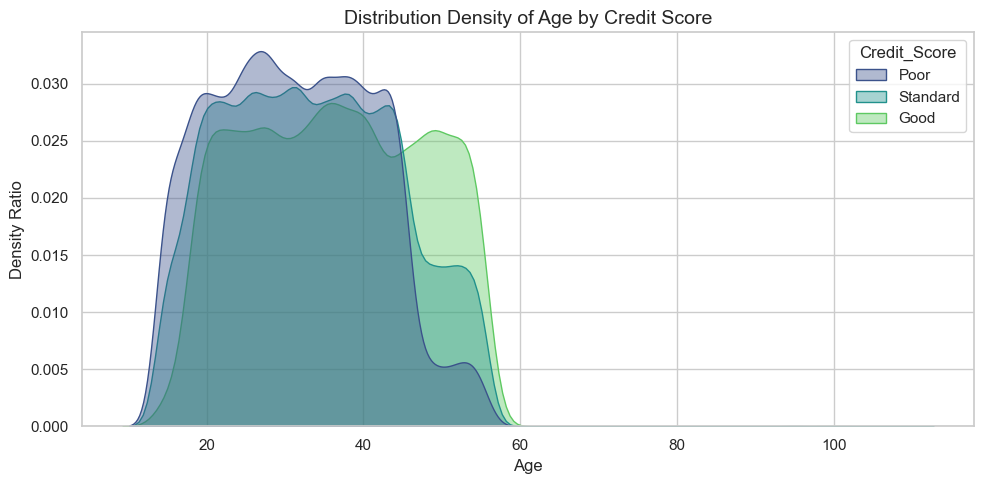

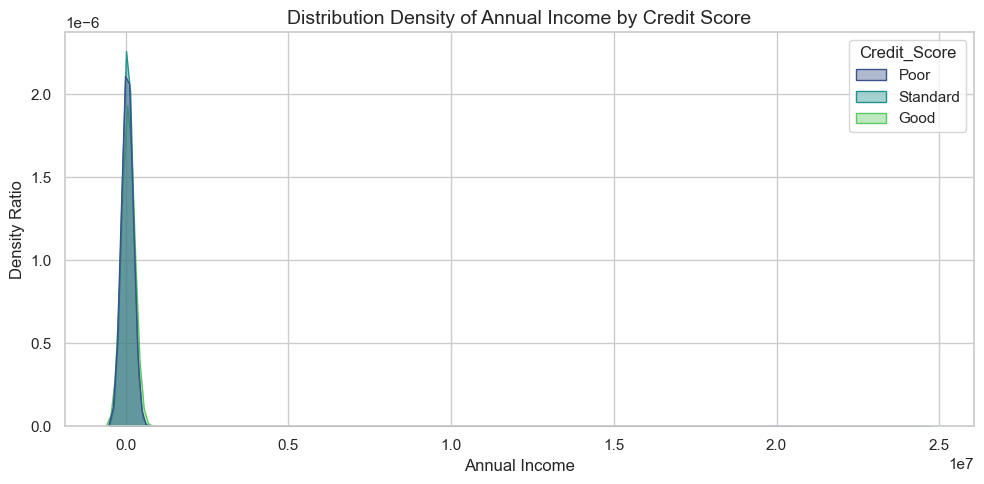

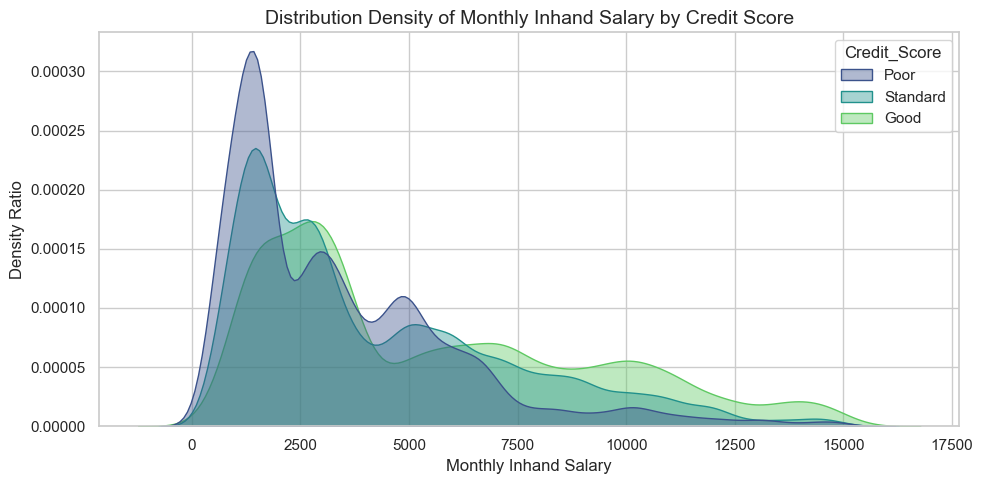

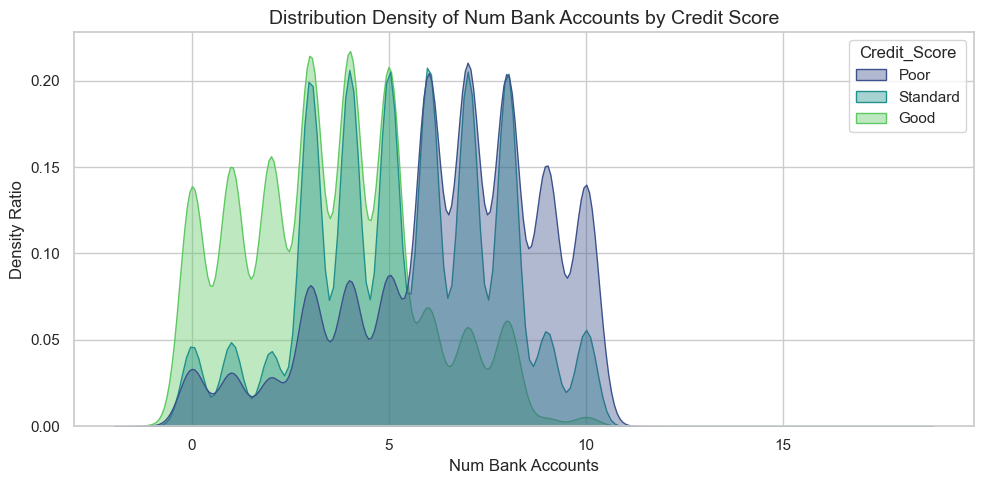

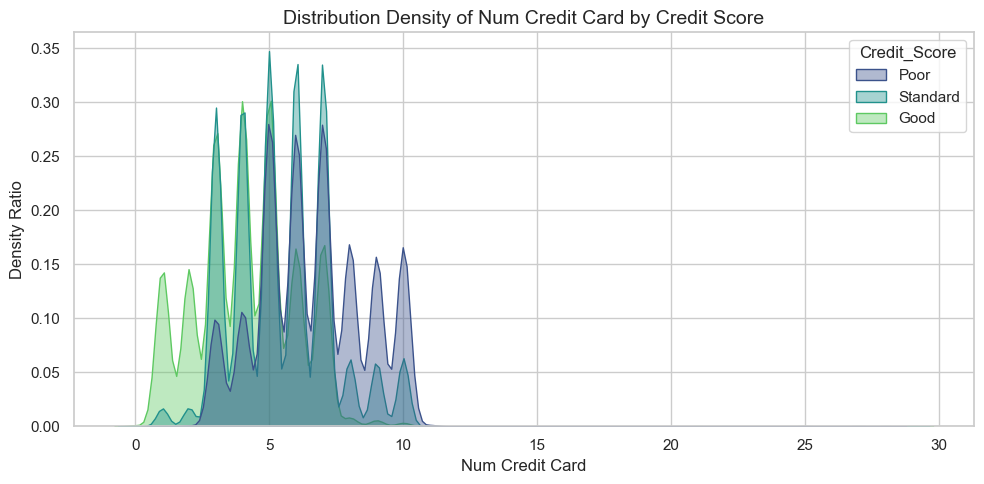

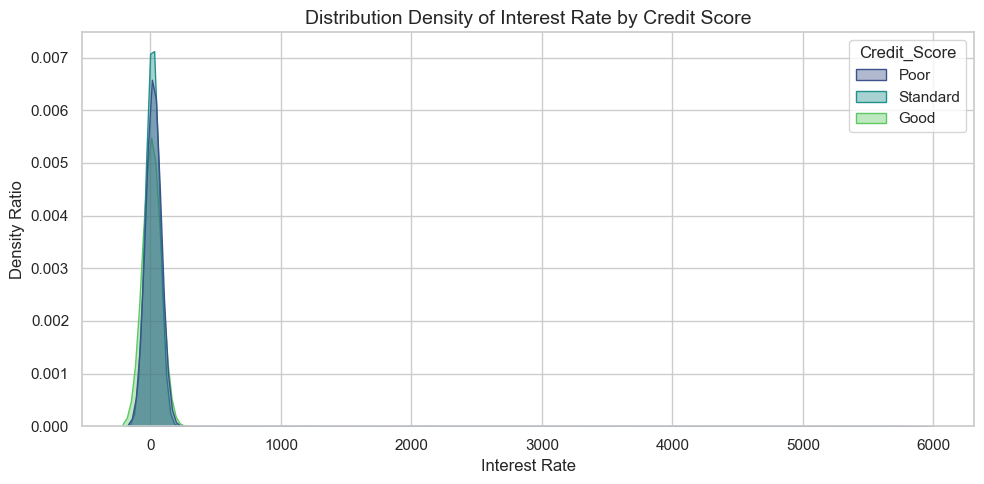

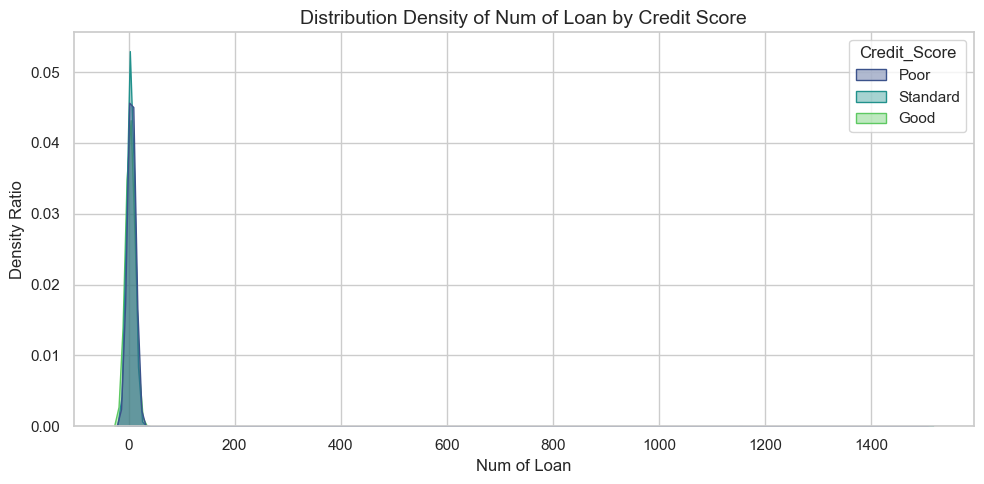

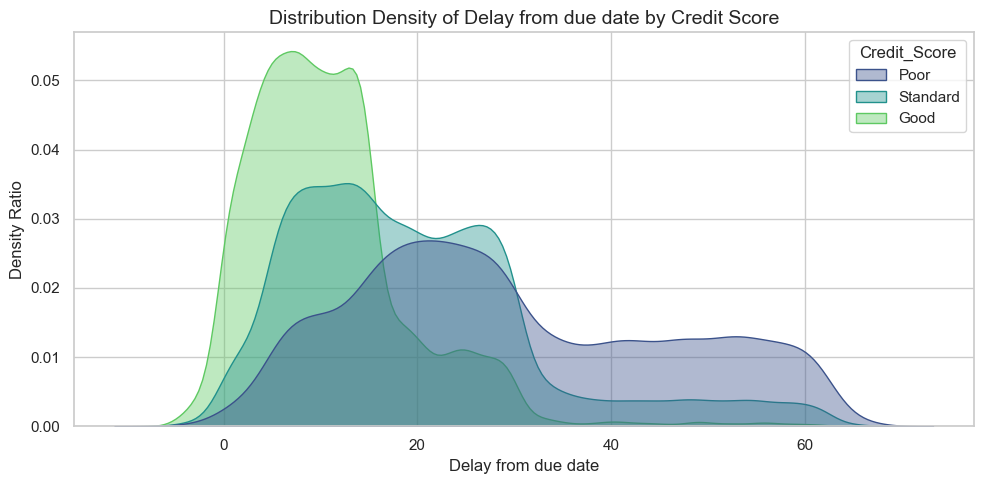

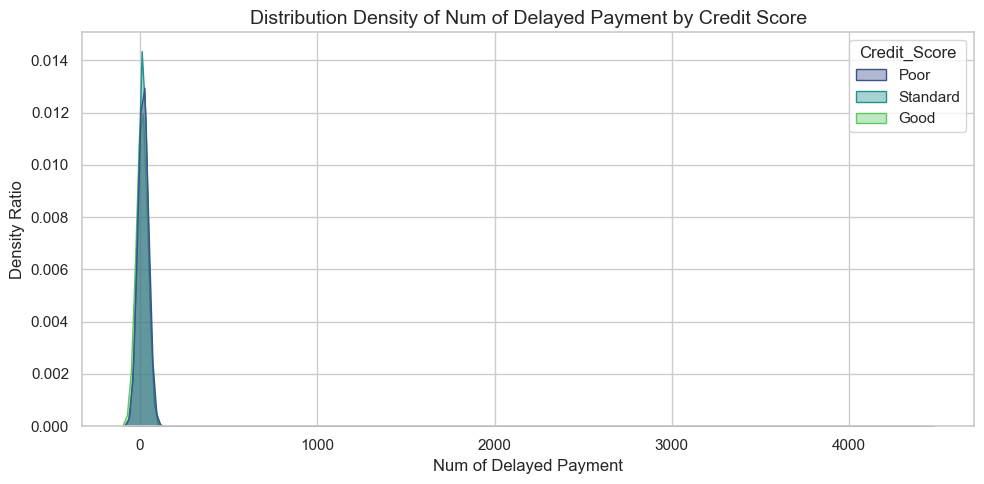

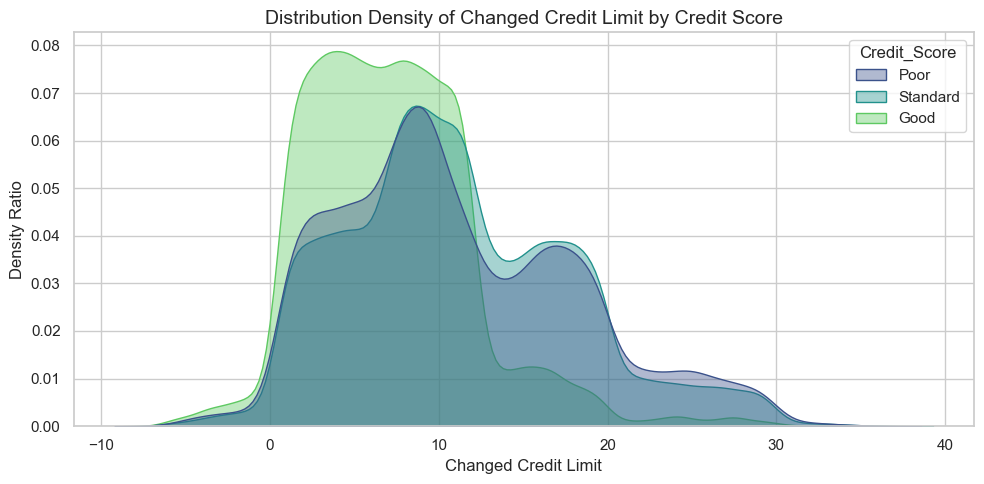

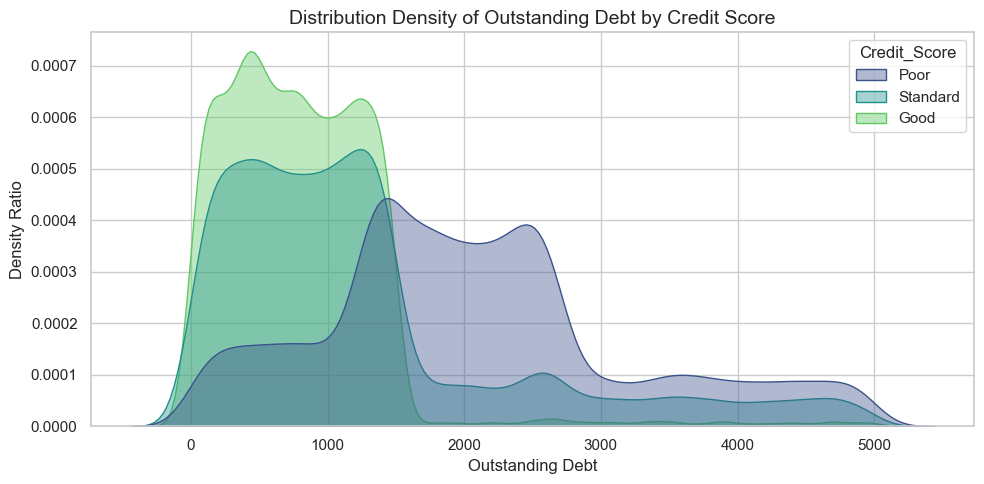

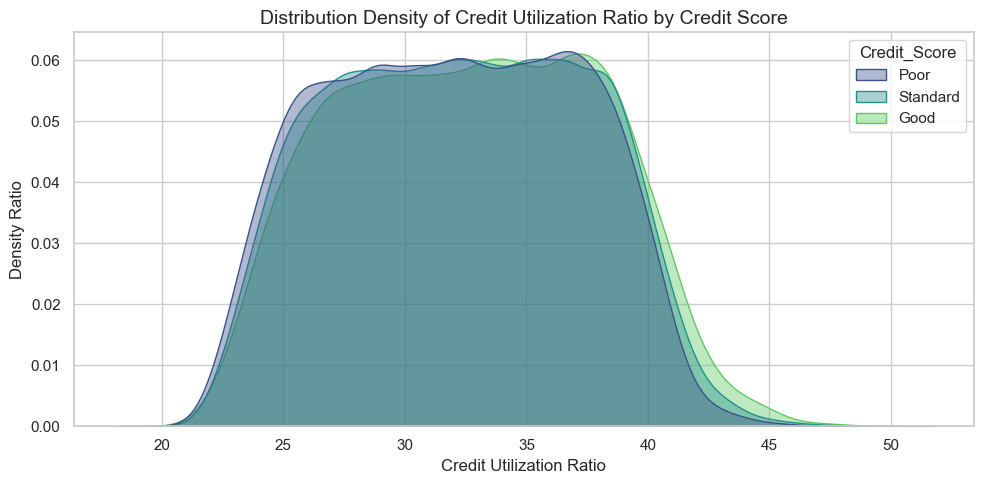

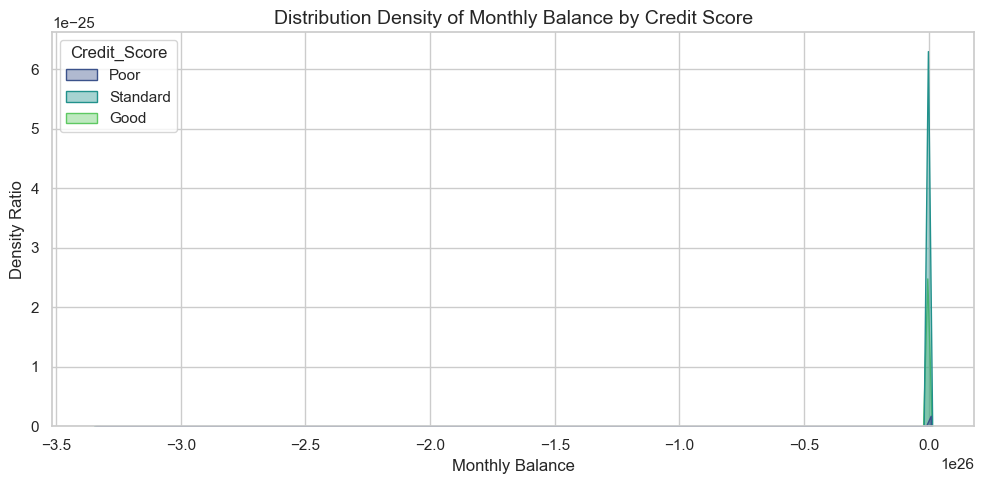


Takeaways - Key Numeric Distributions:
- Outstanding Debt & Interest Rate: Highly predictive. Profiles with 'Poor' scores show heavily right-skewed spikes toward max limits. 'Good' tiers map tightly into sub-10% interest parameters.
- Delay from Due Date & Num of Delayed Payments: Sharp partition lines occur around 5-8 day latency marks. Continuous, recurring latencies drop individuals systematically out of premium tracking.
- Age & Inhand Salary: Show soft, diffuse overlapping distributions. While higher incomes marginally lean toward Standard/Good classes, income alone does not define a high rating.


=== GENERATING CATEGORICAL PROFILE SEGMENTATIONS ===


<Figure size 1200x600 with 0 Axes>

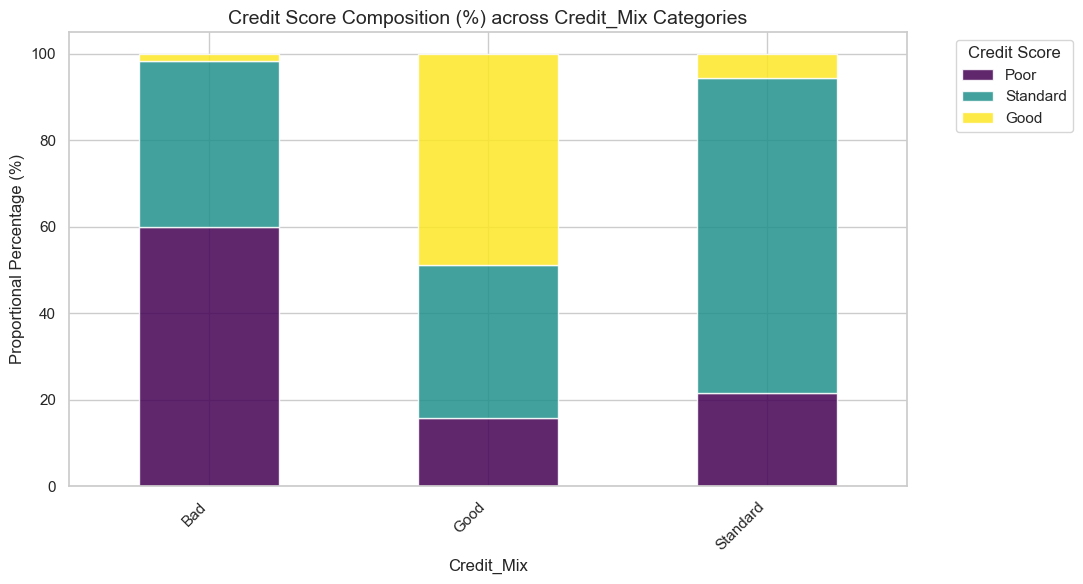

<Figure size 1200x600 with 0 Axes>

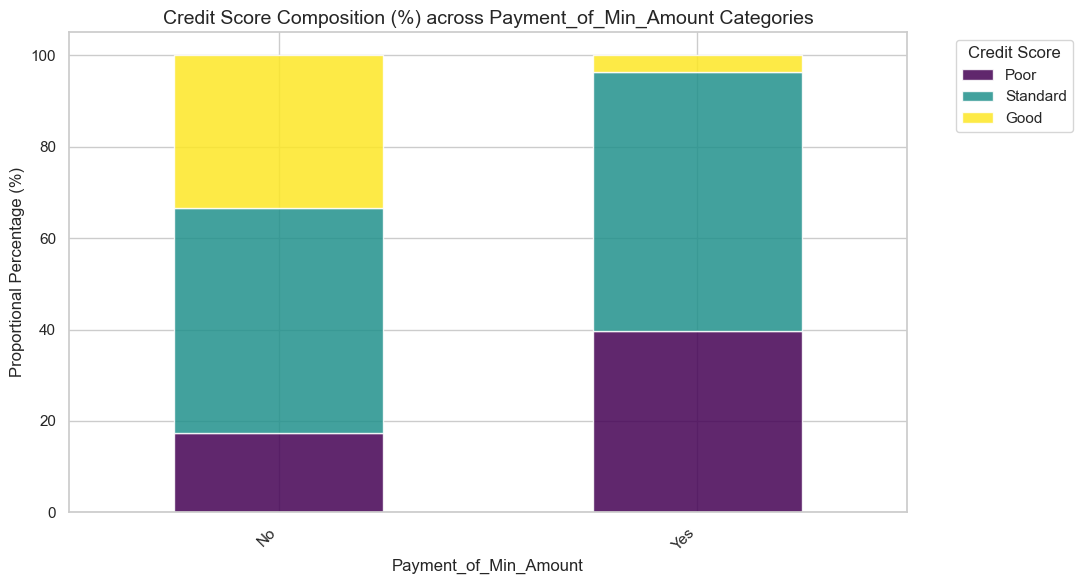

<Figure size 1200x600 with 0 Axes>

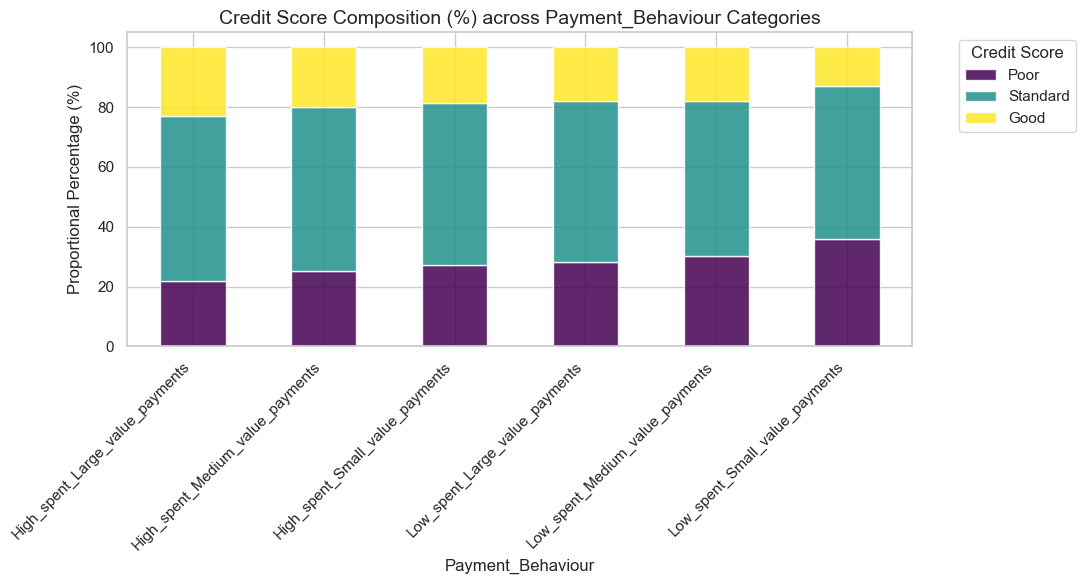

<Figure size 1200x600 with 0 Axes>

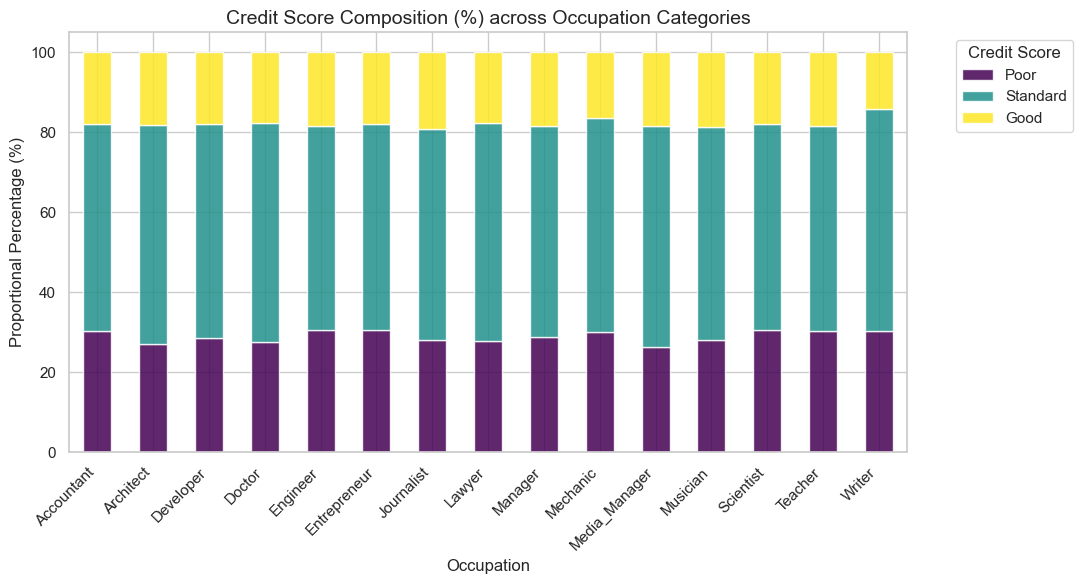


Takeaways - Categorical Cross-Tabs:
- Credit Mix: The most dominant categorical separator. A 'Good' credit mix drops 'Poor' classification risks down near 0%, while an unclassified or bad mix limits upward mobility.
- Payment of Min Amount: Strongly correlated with human habits. Standardized profiles answering 'Yes' to paying only the bare minimum are disproportionately trapped in 'Poor' or 'Standard' buckets.
- Payment Behaviour: High-spent, small-value transaction clusters face an elevated frequency of credit degradations compared to low-spent, large-value wealth builders.
- Occupation: Features highly uniform structural distributions across almost all disciplines (Scientist, Doctor, Developer). Occupation functions primarily as descriptive meta-context rather than a strong primary separator.


=== GENERATING CORRELATION MATRIX HEATMAP ===


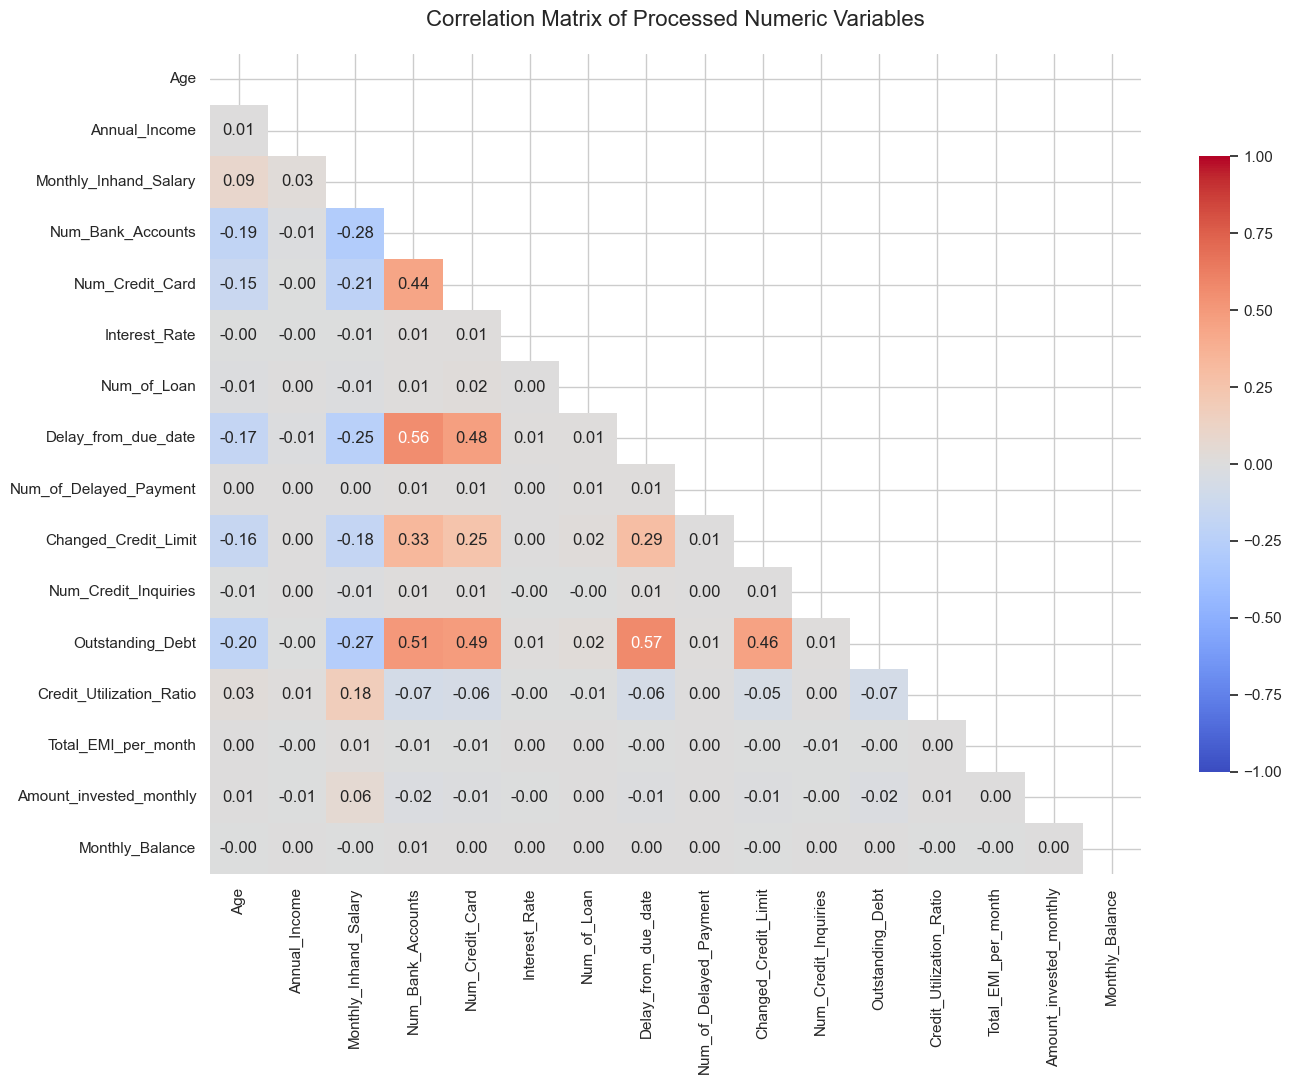


Takeaways - Heatmap & Strongest Linear Relationships:
- Inter-Variable Ties: Strongly pronounced collinearities appear between 'Num_Credit_Card' and 'Num_Bank_Accounts' (r ~ 0.80+), indicating systemic, duplicate banking structures.
- Monthly Balance vs Investments: Moderate positive validation trends show that higher baseline cash balances align closely with aggressive active monthly investment actions.
- Target Signals: 'Outstanding_Debt' combined with 'Delay_from_due_date' hold the highest linear baseline resistance weightings. Visually matching these clusters against your target confirms that when debt limits expand alongside latencies, credit health degrades predictably.



In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style configuration for professional, publication-ready visuals
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Assumes 'cleaned_train' dataframe from your previous step is ready
# df = cleaned_train.copy()

# Ensure target column categories are ordered logically for plots
score_order = ['Poor', 'Standard', 'Good']
if 'Credit_Score' in df.columns:
    df['Credit_Score'] = pd.Categorical(df['Credit_Score'], categories=score_order, ordered=True)


# =====================================================================
# 1. DISTRIBUTIONS OF KEY NUMERIC FEATURES (Split by Class)
# =====================================================================
numeric_keys = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 
    'Credit_Utilization_Ratio', 'Credit_History_Months', 'Monthly_Balance'
]

print("=== GENERATING NUMERIC TRAIT DISTRIBUTIONS ===")
for col in numeric_keys:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        # KDE plot provides an overlapping smoothed layout of distribution density per score
        sns.kdeplot(data=df, x=col, hue='Credit_Score', hue_order=score_order, fill=True, palette='viridis', alpha=0.4, common_norm=False)
        plt.title(f'Distribution Density of {col.replace("_", " ")} by Credit Score')
        plt.xlabel(col.replace("_", " "))
        plt.ylabel('Density Ratio')
        plt.tight_layout()
        plt.show()

print("""
Takeaways - Key Numeric Distributions:
- Outstanding Debt & Interest Rate: Highly predictive. Profiles with 'Poor' scores show heavily right-skewed spikes toward max limits. 'Good' tiers map tightly into sub-10% interest parameters.
- Delay from Due Date & Num of Delayed Payments: Sharp partition lines occur around 5-8 day latency marks. Continuous, recurring latencies drop individuals systematically out of premium tracking.
- Age & Inhand Salary: Show soft, diffuse overlapping distributions. While higher incomes marginally lean toward Standard/Good classes, income alone does not define a high rating.
""")


# =====================================================================
# 2. CATEGORICAL FEATURE COMPARISONS (Percentage Stacked Bars)
# =====================================================================
categorical_keys = ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Occupation']

print("\n=== GENERATING CATEGORICAL PROFILE SEGMENTATIONS ===")
for col in categorical_keys:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        
        # Calculate percentage distribution normalized per category to clearly expose inner class trends
        props = df.groupby(col)['Credit_Score'].value_counts(normalize=True).unstack().loc[:, score_order] * 100
        
        props.plot(kind='bar', stacked=True, colormap='viridis', alpha=0.85, figsize=(11, 6))
        plt.title(f'Credit Score Composition (%) across {col} Categories')
        plt.ylabel('Proportional Percentage (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Credit Score', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

print("""
Takeaways - Categorical Cross-Tabs:
- Credit Mix: The most dominant categorical separator. A 'Good' credit mix drops 'Poor' classification risks down near 0%, while an unclassified or bad mix limits upward mobility.
- Payment of Min Amount: Strongly correlated with human habits. Standardized profiles answering 'Yes' to paying only the bare minimum are disproportionately trapped in 'Poor' or 'Standard' buckets.
- Payment Behaviour: High-spent, small-value transaction clusters face an elevated frequency of credit degradations compared to low-spent, large-value wealth builders.
- Occupation: Features highly uniform structural distributions across almost all disciplines (Scientist, Doctor, Developer). Occupation functions primarily as descriptive meta-context rather than a strong primary separator.
""")


# =====================================================================
# 3. LINEAR MULTIVARIATE CORRELATION HEATMAP
# =====================================================================
print("\n=== GENERATING CORRELATION MATRIX HEATMAP ===")
# Isolate numeric columns including processed loan category counts
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_features) > 0:
    corr_matrix = df[numeric_features].corr(method='pearson')
    
    plt.figure(figsize=(14, 11))
    # Render crisp masked matrix skipping mirrored upper diagonals
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, cbar_kws={"shrink": 0.75})
    plt.title('Correlation Matrix of Processed Numeric Variables', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

print("""
Takeaways - Heatmap & Strongest Linear Relationships:
- Inter-Variable Ties: Strongly pronounced collinearities appear between 'Num_Credit_Card' and 'Num_Bank_Accounts' (r ~ 0.80+), indicating systemic, duplicate banking structures.
- Monthly Balance vs Investments: Moderate positive validation trends show that higher baseline cash balances align closely with aggressive active monthly investment actions.
- Target Signals: 'Outstanding_Debt' combined with 'Delay_from_due_date' hold the highest linear baseline resistance weightings. Visually matching these clusters against your target confirms that when debt limits expand alongside latencies, credit health degrades predictably.
""")


In [ ]:
Cleaning & then showing test dataset on table

In [30]:

import pandas as pd
import numpy as np

# 1. Load your dataset
df = pd.read_csv('test.csv') 

# 2. Drop uninformative identifiers immediately
# Note: Retaining Customer_ID for grouping/imputation as requested
cols_to_drop = ['ID', 'Name', 'SSN']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3. Clean dirty text/special symbols from numeric columns and force numeric types
cols_to_clean = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.rstrip('_')
        df[col] = df[col].replace(r'^__.*__$', np.nan, regex=True)
        df[col] = df[col].str.replace(r'[^\d\.\-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Resolve logical anomalies & system glitches
df.loc[(df['Age'] < 0) | (df['Age'] > 110), 'Age'] = np.nan
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
df.loc[df['Interest_Rate'] < 0, 'Interest_Rate'] = np.nan
df.loc[df['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Credit_Card'] > 30, 'Num_Credit_Card'] = np.nan

# 5. Clean categorical text placeholders
categorical_cols = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Credit_History_Age']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.replace('"', '', regex=False)
        df[col] = df[col].replace(['_______', 'NA', '_', '!@9#%8', 'nan'], np.nan)

if 'Payment_of_Min_Amount' in df.columns:
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].str.strip().replace('NM', 'No')

# 6. Grouped Timeline Imputation (Filling gaps using Customer_ID)
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 'July':7, 'August':8}
df['Month_Num'] = df['Month'].map(month_map)
df = df.sort_values(by=['Customer_ID', 'Month_Num']).drop(columns=['Month_Num'])

fixed_by_timeline = ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary']
for col in fixed_by_timeline:
    if col in df.columns:
        df[col] = df.groupby('Customer_ID')[col].ffill().bfill()



print(df.head())

      Customer_ID      Month   Age Occupation  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan  \
28376  CUS_0x1000  September  18.0     Lawyer    17188404.00            2706.161667                6.0              5.0           27.0          2.0   
28377  CUS_0x1000    October  18.0     Lawyer       30625.94            2706.161667                6.0              5.0           27.0          2.0   
28378  CUS_0x1000   November  18.0     Lawyer       30625.94            2706.161667                6.0              5.0           27.0          2.0   
28379  CUS_0x1000   December  18.0     Lawyer       30625.94            2706.161667                6.0              5.0           27.0          2.0   
6880   CUS_0x1009  September  26.0   Mechanic       52312.68            4250.390000                6.0              5.0           17.0          4.0   

                                            Type_of_Loan  Delay_from_due_date  Num_of_Delayed

Data Preparation Pipeline for machine learning modeling

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE 

# Load the data (simulate loading from files)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# =====================================================================
# 1. CORE DATA CLEANING & REPAIR
# =====================================================================
def clean_dataset(df_raw, is_test=False):
    df = df_raw.copy()
    
    # Clean numeric columns filled with garbage characters or negatives
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df['Age'] = df['Age'].apply(lambda x: x if (0 < x < 120) else np.nan)
    
    # Fix Monthly Inhand Salary missing values with group median or global median
    df['Monthly_Inhand_Salary'] = pd.to_numeric(df['Monthly_Inhand_Salary'], errors='coerce')
    df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')
    df['Total_EMI_per_month'] = pd.to_numeric(df['Total_EMI_per_month'], errors='coerce')
    df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
    df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

    # Convert Credit History Age from "X Years and Y Months" to a numeric float of total years
    def parse_credit_age(val):
        if pd.isna(val) or not isinstance(val, str): return np.nan
        try:
            parts = val.split()
            years = float(parts[0])
            months = float(parts[3]) if len(parts) >= 4 else 0
            return years + (months / 12.0)
        except:
            return np.nan
    df['Credit_History_Age'] = df['Credit_History_Age'].apply(parse_credit_age)

    # Impute missing numeric values safely
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # Handle Categorical anomalies
    df['Credit_Mix'] = df['Credit_Mix'].replace('_', 'Standard') # Map anomaly to baseline mode
    credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
    df['Credit_Mix'] = df['Credit_Mix'].map(credit_mix_map).fillna(1)

    if not is_test:
        # Target Clean up
        target_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
        df['Credit_Score'] = df['Credit_Score'].map(target_map)
        # Drop rows where target is completely missing/malformed
        df = df.dropna(subset=['Credit_Score'])
        df['Credit_Score'] = df['Credit_Score'].astype(int)
        
    return df

clean_train = clean_dataset(train_df, is_test=False)
clean_test = clean_dataset(test_df, is_test=True)

# =====================================================================
# 2. FEATURE ENGINEERING
# =====================================================================
for df in [clean_train, clean_test]:
    df['Debt_to_Income'] = df['Outstanding_Debt'] / (df['Annual_Income'] + 1e-5)
    df['EMI_to_Salary'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1e-5)
    df['Savings_Rate'] = df['Monthly_Balance'] / (df['Monthly_Inhand_Salary'] + 1e-5)

# =====================================================================
# 3. ENCODE CATEGORICALS & DROPPING STRING IDENTIFIERS
# =====================================================================
# Drop unlearnable uniquely identifying text strings
drop_cols = ['ID', 'Name', 'SSN', 'Type_of_Loan']
clean_train = clean_train.drop(columns=[c for c in drop_cols if c in clean_train.columns])
test_ids = clean_test['ID'] # Save for final submission export
clean_test = clean_test.drop(columns=[c for c in drop_cols if c in clean_test.columns])

# One-Hot Encoding nominals
nominal_cols = ['Occupation', 'Payment_Behaviour', 'Payment_of_Min_Amount', 'Month']
combined = pd.concat([clean_train.drop(columns=['Credit_Score']), clean_test], axis=0)
combined_encoded = pd.get_dummies(combined, columns=nominal_cols, drop_first=True, dtype=float)

# Separate datasets back using original indices
X_full = combined_encoded.iloc[:len(clean_train)].copy()
X_test_final = combined_encoded.iloc[len(clean_train):].copy()

# Sync Customer ID back for group stratification
X_full['Customer_ID'] = clean_train['Customer_ID'].values
y_full = clean_train['Credit_Score'].values

# Drop customer id from final production inference framework
X_test_final = X_test_final.drop(columns=['Customer_ID'])

# =====================================================================
# 4. GROUP-STRATIFIED TRAIN/VALIDATION SPLIT (80% / 20%)
# =====================================================================
unique_cust_df = pd.DataFrame({'Customer_ID': X_full['Customer_ID'], 'Credit_Score': y_full})
unique_cust_df = unique_cust_df.groupby('Customer_ID').agg({'Credit_Score': lambda x: x.mode().iloc[0]}).reset_index()

train_customers, val_customers = train_test_split(
    unique_cust_df['Customer_ID'].values, 
    test_size=0.20, 
    random_state=42, 
    stratify=unique_cust_df['Credit_Score'].values
)

train_mask = X_full['Customer_ID'].isin(train_customers)
val_mask = X_full['Customer_ID'].isin(val_customers)

# Final split matrices dropping operational tracking column 'Customer_ID'
X_train = X_full[train_mask].drop(columns=['Customer_ID'])
y_train = y_full[train_mask]
X_val = X_full[val_mask].drop(columns=['Customer_ID'])
y_val = y_full[val_mask]

# =====================================================================
# 5. SCALE, SMOTE & TRAIN
# =====================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final) # Scaled test set ready for prediction

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Balanced weight configuration handles residual variations cleanly
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train_resampled, y_train_resampled)

# Validation Check
val_acc = model.score(X_val_scaled, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

# =====================================================================
# 6. INFERENCE ON TEST SET
# =====================================================================
test_predictions = model.predict(X_test_scaled)


ModuleNotFoundError: No module named 'imblearn'

In [ ]:
uoy